In [1]:
import pandas as pd

data = {
    "Name": ["A", "B", "C", "D", "E"],
    "Age": [25, None, 30, 28, None],
    "Salary": [50000, 60000, None, 52000, 58000]
}

df = pd.DataFrame(data)

print(df.isnull())
print(df.isnull().sum())

    Name    Age  Salary
0  False  False   False
1  False   True   False
2  False  False    True
3  False  False   False
4  False   True   False
Name      0
Age       2
Salary    1
dtype: int64


In [2]:
df_drop_rows = df.dropna()
print(df_drop_rows)

  Name   Age   Salary
0    A  25.0  50000.0
3    D  28.0  52000.0


In [3]:
df_drop_cols = df.dropna(axis=1)
print(df_drop_cols)

  Name
0    A
1    B
2    C
3    D
4    E


In [4]:
df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Salary"].fillna(df["Salary"].mean(), inplace=True)

print(df)

  Name        Age   Salary
0    A  25.000000  50000.0
1    B  27.666667  60000.0
2    C  30.000000  55000.0
3    D  28.000000  52000.0
4    E  27.666667  58000.0


/tmp/ipykernel_6332/1051743666.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_6332/1051743666.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [5]:
df_ffill = df.fillna(method="ffill")
df_bfill = df.fillna(method="bfill")

print(df_ffill)
print(df_bfill)

  Name        Age   Salary
0    A  25.000000  50000.0
1    B  27.666667  60000.0
2    C  30.000000  55000.0
3    D  28.000000  52000.0
4    E  27.666667  58000.0
  Name        Age   Salary
0    A  25.000000  50000.0
1    B  27.666667  60000.0
2    C  30.000000  55000.0
3    D  28.000000  52000.0
4    E  27.666667  58000.0


/tmp/ipykernel_6332/2128180805.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method="ffill")
/tmp/ipykernel_6332/2128180805.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method="bfill")


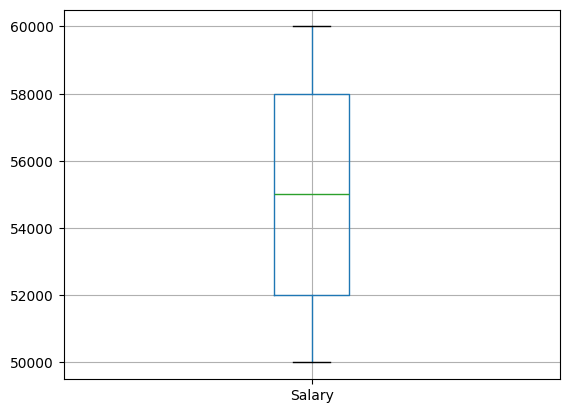

In [6]:
import matplotlib.pyplot as plt

df.boxplot(column=["Salary"])
plt.show()

In [8]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Salary"] < lower) | (df["Salary"] > upper)]
print(outliers)

Empty DataFrame
Columns: [Name, Age, Salary]
Index: []


In [9]:
df_no_outliers = df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]
print(df_no_outliers)

  Name        Age   Salary
0    A  25.000000  50000.0
1    B  27.666667  60000.0
2    C  30.000000  55000.0
3    D  28.000000  52000.0
4    E  27.666667  58000.0


In [10]:
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df["Salary"]))
print(df[z > 3])

Empty DataFrame
Columns: [Name, Age, Salary]
Index: []


In [11]:
df["Salary"] = np.where(df["Salary"] > upper, upper, df["Salary"])
df["Salary"] = np.where(df["Salary"] < lower, lower, df["Salary"])

print(df)

  Name        Age   Salary
0    A  25.000000  50000.0
1    B  27.666667  60000.0
2    C  30.000000  55000.0
3    D  28.000000  52000.0
4    E  27.666667  58000.0


In [12]:
from sklearn.preprocessing import LabelEncoder

data = {
    "Department": ["HR", "IT", "Sales", "HR", "IT"]
}

df = pd.DataFrame(data)

le = LabelEncoder()

df["Dept_Label"] = le.fit_transform(df["Department"])

print(df)

  Department  Dept_Label
0         HR           0
1         IT           1
2      Sales           2
3         HR           0
4         IT           1


In [13]:
df_onehot = pd.get_dummies(df["Department"])

print(df_onehot)

      HR     IT  Sales
0   True  False  False
1  False   True  False
2  False  False   True
3   True  False  False
4  False   True  False


In [14]:
df = pd.get_dummies(df, columns=["Department"])
print(df)

   Dept_Label  Department_HR  Department_IT  Department_Sales
0           0           True          False             False
1           1          False           True             False
2           2          False          False              True
3           0           True          False             False
4           1          False           True             False


In [15]:
data = {
    "Department": ["HR", "IT", "Sales"],
    "Role": ["Manager", "Developer", "Executive"]
}

df = pd.DataFrame(data)

encoded = pd.get_dummies(df)

print(encoded)

   Department_HR  Department_IT  Department_Sales  Role_Developer  \
0           True          False             False           False   
1          False           True             False            True   
2          False          False              True           False   

   Role_Executive  Role_Manager  
0           False          True  
1           False         False  
2            True         False  


In [16]:
top_categories = df["Department"].value_counts().nlargest(2).index

df["Dept_Grouped"] = df["Department"].apply(
    lambda x: x if x in top_categories else "Other"
)

print(df)

  Department       Role Dept_Grouped
0         HR    Manager           HR
1         IT  Developer           IT
2      Sales  Executive        Other


In [17]:
from sklearn.preprocessing import MinMaxScaler

data = {
    "Age": [22, 35, 40, 28],
    "Salary": [40000, 80000, 60000, 50000]
}

df = pd.DataFrame(data)

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df)

print(scaled)

[[0.         0.        ]
 [0.72222222 1.        ]
 [1.         0.5       ]
 [0.33333333 0.25      ]]


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(df)

print(scaled)

[[-1.35375921 -1.18321596]
 [ 0.5488213   1.52127766]
 [ 1.28058303  0.16903085]
 [-0.47564513 -0.50709255]]


In [19]:
print("Original Data")
print(df)

print("Scaled Data")
print(pd.DataFrame(scaled))

Original Data
   Age  Salary
0   22   40000
1   35   80000
2   40   60000
3   28   50000
Scaled Data
          0         1
0 -1.353759 -1.183216
1  0.548821  1.521278
2  1.280583  0.169031
3 -0.475645 -0.507093


In [20]:
df["Salary"] = scaler.fit_transform(df[["Salary"]])

print(df)

   Age    Salary
0   22 -1.183216
1   35  1.521278
2   40  0.169031
3   28 -0.507093


In [21]:
cols = ["Age", "Salary"]

df[cols] = scaler.fit_transform(df[cols])

print(df)


        Age    Salary
0 -1.353759 -1.183216
1  0.548821  1.521278
2  1.280583  0.169031
3 -0.475645 -0.507093


In [22]:
df1 = pd.DataFrame({"ID":[1,2], "Name":["A","B"]})
df2 = pd.DataFrame({"ID":[3,4], "Name":["C","D"]})

result = pd.concat([df1, df2])

print(result)

   ID Name
0   1    A
1   2    B
0   3    C
1   4    D


In [23]:
df3 = pd.DataFrame({"Salary":[50000,60000]})

result = pd.concat([df1, df3], axis=1)

print(result)

   ID Name  Salary
0   1    A   50000
1   2    B   60000


In [24]:
emp = pd.DataFrame({
    "ID":[1,2,3],
    "Name":["A","B","C"]
})

salary = pd.DataFrame({
    "ID":[1,2,3],
    "Salary":[50000,60000,70000]
})

merged = pd.merge(emp, salary, on="ID")

print(merged)

   ID Name  Salary
0   1    A   50000
1   2    B   60000
2   3    C   70000


In [25]:
left = pd.merge(emp, salary, on="ID", how="left")

print(left)

   ID Name  Salary
0   1    A   50000
1   2    B   60000
2   3    C   70000


In [26]:
merged = merged.drop_duplicates()

print(merged)

   ID Name  Salary
0   1    A   50000
1   2    B   60000
2   3    C   70000


In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = {
    "Age":[25, None, 35, 40, None],
    "Salary":[50000, 200000, 55000, 52000, 51000],
    "Department":["HR","IT","Sales","HR","IT"]
}

df = pd.DataFrame(data)

# Missing values
df["Age"].fillna(df["Age"].mean(), inplace=True)

# Outlier detection
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["Salary"] >= lower) & (df["Salary"] <= upper)]

# Encoding
df = pd.get_dummies(df, columns=["Department"])

# Scaling
scaler = StandardScaler()

df[["Age","Salary"]] = scaler.fit_transform(df[["Age","Salary"]])

print(df)

        Age    Salary  Department_HR  Department_IT  Department_Sales
0 -1.543033 -1.069045           True          False             False
2  0.308607  1.603567          False          False              True
3  1.234427  0.000000           True          False             False
4  0.000000 -0.534522          False           True             False


/tmp/ipykernel_6332/663458435.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
